In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Parâmetros do problema
r = 0.005           # taxa de resfriamento (1/s)
T_amb = 25          # temperatura ambiente (°C)
T0 = 90             # temperatura inicial do café (°C) NÃO DATA NO PROBLEMA 
t_span = (0, 1000)  # intervalo de tempo (s)
t_eval = np.linspace(*t_span, 100)  # pontos para avaliação




In [3]:
# EDO: dT/dt = r*(T_amb - T)
def cooling_ode(t, T):
    return r * (T_amb - T)

# Solução analítica
def T_analytical(t):
    return T_amb + (T0 - T_amb) * np.exp(-r * t)

# Resolver numericamente com RK4 (via solve_ivp com método 'RK45')
sol = solve_ivp(
    cooling_ode,
    t_span,
    [T0],
    method='RK45',
    t_eval=t_eval
)

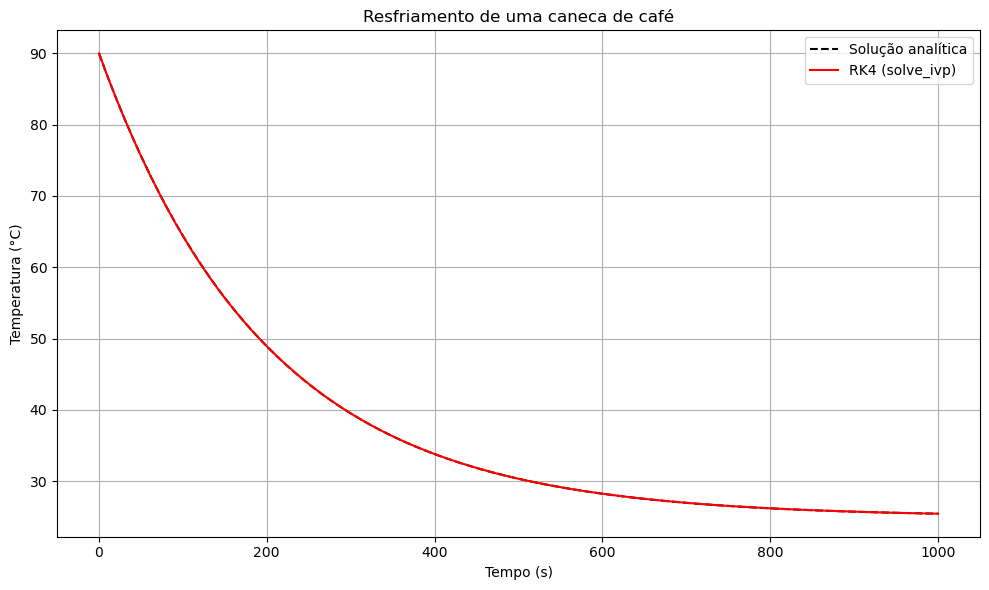

In [4]:
# Avaliar solução analítica nos mesmos tempos
T_exact = T_analytical(t_eval)

# Plotando
plt.figure(figsize=(10, 6))
plt.plot(t_eval, T_exact, 'k--', label='Solução analítica')
plt.plot(sol.t, sol.y[0], 'r-', label='RK4 (solve_ivp)')
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Resfriamento de uma caneca de café')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



#passo 1

In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Parâmetros
T_amb = 25
r = 0.005
T0 = 90

In [7]:
# Solução analítica - calculada com a equação diferencial
# que descreve o resfriamento do café
def analytical_solution(t):
    return T_amb + (T0 - T_amb) * np.exp(-r * t)

In [8]:
# Tempo e dados
np.random.seed(42)
t_train = np.linspace(0, 300, 10)
T_clean = analytical_solution(t_train)
T_noisy = T_clean + np.random.normal(0, 0.5, size=T_clean.shape)

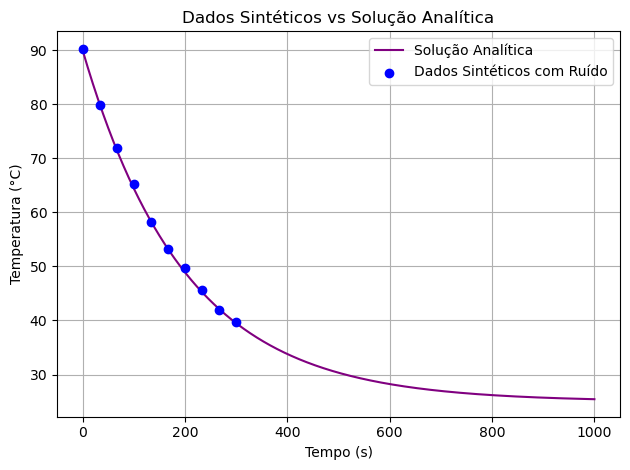

In [9]:
# Plot
t_plot = np.linspace(0, 1000, 1000)
plt.plot(t_plot, analytical_solution(t_plot), label='Solução Analítica', color='purple', zorder=2)
plt.scatter(t_train, T_noisy, label='Dados Sintéticos com Ruído', color='blue', zorder=3)
plt.xlabel("Tempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Dados Sintéticos vs Solução Analítica")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#passo 3